<h3>Brain Tumor Detection</h3>

A project with the aim of developing an app that can detect the presence (and type) of brain tumor present in a brain image.

<h5>Data Import + Initial 'Preparation' + EDA:

In [1]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pickle

Load data:

In [2]:
ALLOWED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.gif'}
# Import images into a datframe.

def load_images_to_df(base_dir='Data', nested_dir='BTC MRI Data Bhuvaji'):
    """
    Walks base_dir expecting structure:
      Misc data/
        BTC MRI Data Bhuvaji/
          Training/<label>/*.jpg
          Testing/<label>/*.jpg
    Returns a pandas DataFrame with columns: image (numpy array), label (subfolder name), split ('training'|'testing'), path.
    """
    records = []
    root = os.path.join(base_dir, nested_dir) if nested_dir else base_dir
    if not os.path.isdir(root):
        # fallback to base_dir if nested_dir not present
        if os.path.isdir(base_dir):
            root = base_dir
        else:
            return pd.DataFrame(records)

    for entry in sorted(os.listdir(root)):
        split_dir = os.path.join(root, entry)
        if not os.path.isdir(split_dir):
            continue
        entry_l = entry.lower()
        if entry_l not in ('training', 'testing'):
            continue
        split = entry_l  # normalized split name
        for label in sorted(os.listdir(split_dir)):
            label_dir = os.path.join(split_dir, label)
            if not os.path.isdir(label_dir):
                continue
            for fname in sorted(os.listdir(label_dir)):
                path = os.path.join(label_dir, fname)
                if not os.path.isfile(path):
                    continue
                ext = os.path.splitext(fname)[1].lower()
                if ext not in ALLOWED_EXTS:
                    continue
                try:
                    img = Image.open(path).convert('RGB')
                    arr = np.asarray(img)
                except Exception:
                    continue
                records.append({'image': arr, 'label': label, 'split': split, 'path': path})
    return pd.DataFrame(records)


In [3]:
raw_df = load_images_to_df('Data', 'BTC MRI Data Bhuvaji')
print(f"Loaded {len(raw_df)} images")
# example: df.iloc[0]['image'] -> numpy array, df['label'] -> labels

Loaded 3264 images


In [4]:
raw_df.head(10)

,image,label,split,path
0,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...
1,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...
2,"[[[7, 7, 7], [7, 7, 7], [7, 7, 7], [7, 7, 7], ...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...
3,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...
4,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...
5,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...
6,"[[[32, 32, 32], [0, 0, 0], [7, 7, 7], [2, 2, 2...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...
7,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...
8,"[[[166, 166, 166], [254, 254, 254], [31, 31, 3...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...
9,"[[[11, 11, 11], [11, 11, 11], [11, 11, 11], [1...",glioma_tumor,testing,Data\BTC MRI Data Bhuvaji\Testing\glioma_tumor...


Convert from pseudo-RGB to Grayscale:

In [5]:
# Drop unnecessary columns:
data = raw_df.drop(['split','path'],axis=1)
data.head(5)

,image,label
0,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor
1,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor
2,"[[[7, 7, 7], [7, 7, 7], [7, 7, 7], [7, 7, 7], ...",glioma_tumor
3,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor
4,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",glioma_tumor


In [6]:
test_rimage_1 =data['image'][13]
test_rimage_1.shape
# 3 on the end implies they are stored as RGB, but likely that those 3 numbers are identical (pseudo-RGB)

(274, 248, 3)

In [7]:
# Confirm they are all grayscale:
np.allclose(test_rimage_1[..., 0], test_rimage_1[..., 1]) and np.allclose(test_rimage_1[..., 1], test_rimage_1[..., 2]) #Checks if two arrays are equal within a given tolerance

True

In [8]:
# Now reshape the arrays to (H, W, 1) by taking values from any of the 3 channels (doesn't matter as they will all be identical)
data['image'] = data['image'].apply(lambda x: x[:,:,0]) #0, 1 or 2.
data['image'][13].shape
# All good now

(274, 248)

In [9]:
data.head(5)

,image,label
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",glioma_tumor
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",glioma_tumor
2,"[[7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 5, 4, 2, 2,...",glioma_tumor
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",glioma_tumor
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",glioma_tumor


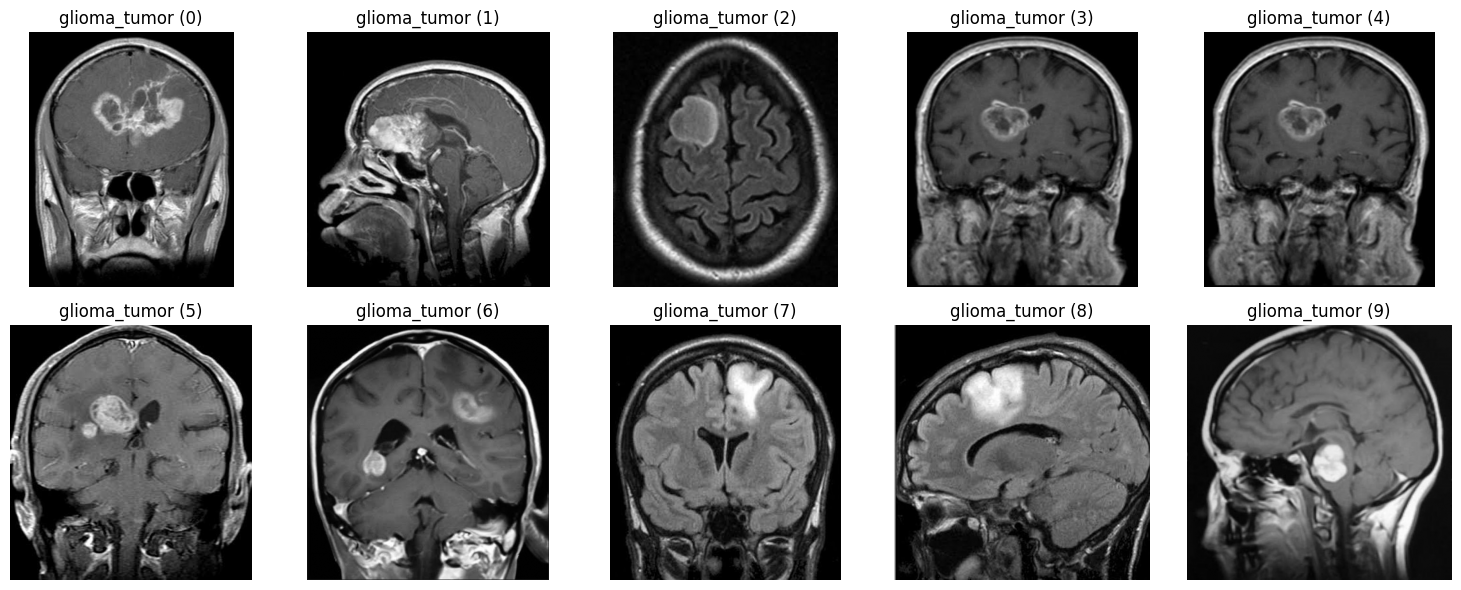

In [10]:
# Visualise some of the images:
import matplotlib.pyplot as plt

imgs = data['image'].iloc[:10].tolist()
labels = data['label'].iloc[:10].tolist()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i, (img, lbl) in enumerate(zip(imgs, labels)):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"{lbl} ({i})")
plt.tight_layout()
plt.show()

# Looks great!!

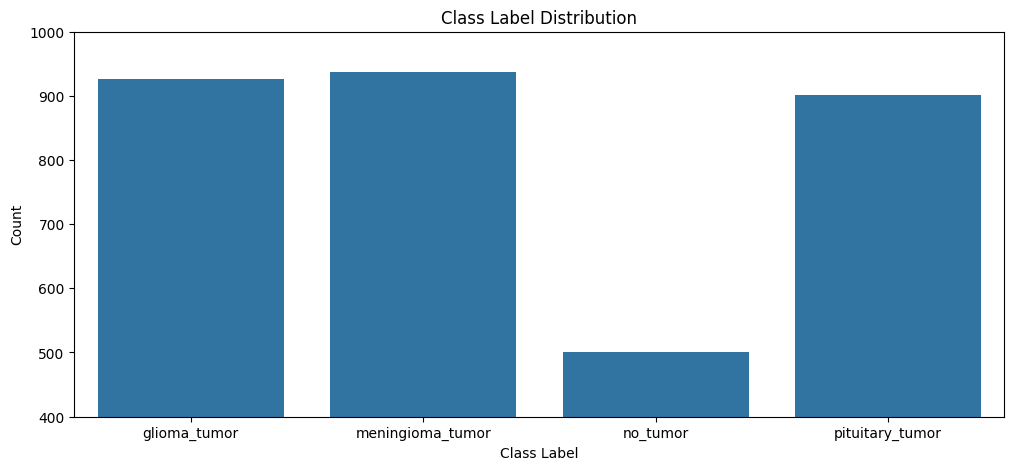

In [11]:
# Observing the class distribution
plt.figure(figsize=(12,5))
sns.countplot(x=data['label'])
plt.title('Class Label Distribution')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.ylim((400,1000))
plt.show()

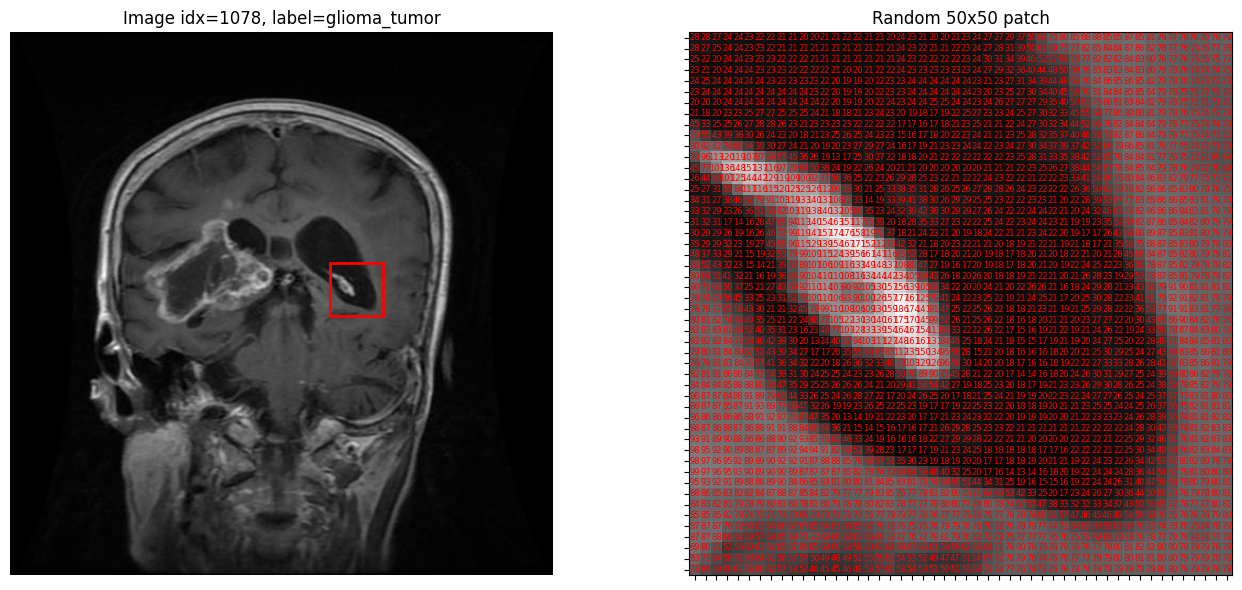

Patch location (row, col): (217, 301)
Patch shape: (50, 50)
Pixel value range in patch: 13 - 186
Data type: uint8


In [12]:
# Viewing pixel values for a random 50x50 patch from a random image
random_idx = np.random.randint(0, len(data))
random_image = data['image'].iloc[random_idx]
random_label = data['label'].iloc[random_idx]

patch_size = 50
h, w = random_image.shape

# Random top-left corner for 20x20 patch
start_row = np.random.randint(0, h - patch_size + 1)
start_col = np.random.randint(0, w - patch_size + 1)

patch = random_image[start_row:start_row + patch_size, start_col:start_col + patch_size]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Full image with selected patch highlighted
ax1.imshow(random_image, cmap='gray')
ax1.set_title(f'Image idx={random_idx}, label={random_label}')
ax1.axis('off')
rect = plt.Rectangle((start_col, start_row), patch_size, patch_size,
                     fill=False, edgecolor='red', linewidth=2)
ax1.add_patch(rect)

# 20x20 patch with pixel annotations
ax2.imshow(patch, cmap='gray')
ax2.set_title(f'Random {patch_size}x{patch_size} patch')
ax2.set_xticks(range(patch_size))
ax2.set_yticks(range(patch_size))
ax2.set_xticklabels([])
ax2.set_yticklabels([])

for i in range(patch_size):
    for j in range(patch_size):
        ax2.text(j, i, int(patch[i, j]), ha="center", va="center", color="red", fontsize=6)

plt.tight_layout()
plt.show()

print(f"Patch location (row, col): ({start_row}, {start_col})")
print(f"Patch shape: {patch.shape}")
print(f"Pixel value range in patch: {patch.min()} - {patch.max()}")
print(f"Data type: {patch.dtype}")

# Hard to plot the whole image as theyare quite large and detailed. We are viewing a small area here.

In [13]:
# The good contrast in most of the images should make distinction between cancerous and non-canerous images by a model possible.

<h5>Data Pre-processing for Modelling

Will be using convoluted neural network (CNN) as the model. Data preparation steps:
1) Train-test split + validation set from train set.
2) Add channel dimension (1 = grayscale, 3 = RGB).
3) Normalise pixel values + make sure datatype = float32.
4) Encode the labels
5) Data augmentation (to reduce overfitting)

In [14]:
# 1) Train-test-split + validation split:

X = data['image']
y = data['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, stratify=y, random_state=13) # Create train and test sets.
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.1, stratify=y_train, random_state=13) # Create val set from train sets.

In [15]:
# 2) Resize to a fixed size, then add a channel dimension (grayscale => 1 channel)
IMG_SIZE = (128, 128)

def resize_stack_with_channel(x_series, size=IMG_SIZE):
	arr = np.stack([
		np.array(Image.fromarray(img).resize(size, Image.BILINEAR))
		for img in x_series
	])
	return arr[..., np.newaxis]  # (N, H, W, 1)

X_train = resize_stack_with_channel(X_train)
X_val = resize_stack_with_channel(X_val)
X_test = resize_stack_with_channel(X_test)

In [16]:
# 3) Normalise the pixel values + make sure dataype = float32:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

In [17]:
# 4) Encode the labels:

from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_int = label_encoder.fit_transform(y_train)
y_val_int = label_encoder.transform(y_val)
y_test_int = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

y_train = to_categorical(y_train_int, num_classes=num_classes)
y_val = to_categorical(y_val_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

class_names = label_encoder.classes_.tolist()

In [18]:
# 5) Data augmentation (ImageDataGenerator):
    # Helps to combat overfitting
    # Introduces slight variablilities in newly generated training images.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator( #If the augmentation is too agressive, early training can be dominated by 'distored' digits, causing poor predictions)
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)
datagen.fit(X_train) #Apply only to the training set, not the validation (or test) set.

In [19]:
print(X_train[1].shape)
print(type(X_train[1].shape))
# This is important as it will determine the input shape of the model.

(128, 128, 1)
<class 'tuple'>


Model Creation

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

In [21]:
# Build CNN model

model = Sequential([
# First Convolutional Block
Conv2D(64, (3, 3), activation='relu', input_shape=X_train[1].shape), #input shape = (h, w, channel) i.e. image size + channel
BatchNormalization(), #Normalizes the layer activations per batch (helps to speed training)
Conv2D(64, (3, 3), activation='relu'),
MaxPooling2D(pool_size=(2, 2)), #Reduces spatial dimension by 2 (H x W -> H/2 x w/2). Reduces computation
Dropout(0.3),

# Second Convolutional Block
Conv2D(64, (3, 3), activation='relu'),
BatchNormalization(),
Conv2D(128, (3, 3), activation='relu'),
MaxPooling2D(pool_size=(2, 2)),
Dropout(0.3),

# Third Convolutional Block
Conv2D(64, (3, 3), activation='relu'),
BatchNormalization(),
Dropout(0.3),

# Flatten and Dense layers
Flatten(),
Dense(64, activation='relu'),
BatchNormalization(),
Dropout(0.5),
Dense(4, activation='softmax')  # 4 classes for the target
])

# Compile the model
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), "accuracy"] #Don't just add 'precision and 'recall', make sure to do the tf imports)
)
# Display model summary
model.summary()

c:\Users\cochr\Data Science Projects\Brain-Tumor-Detection\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,986,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,209,476 (12.24 MB)

 Trainable params: 3,208,964 (12.24 MB)

 Non-trainable params: 512 (2.00 KB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

# Implement early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

commence_model_training = False
load_previous_model = True

if commence_model_training == True:
    trained_model = model.fit(datagen.flow(X_train, y_train, batch_size=64, shuffle = True),
                            epochs=10,
                            validation_data=(X_val, y_val),
                            callbacks=[early_stopping])
if load_previous_model == True:
    trained_model = pickle.load(open("models/trained_model_1.pkl", "rb"))

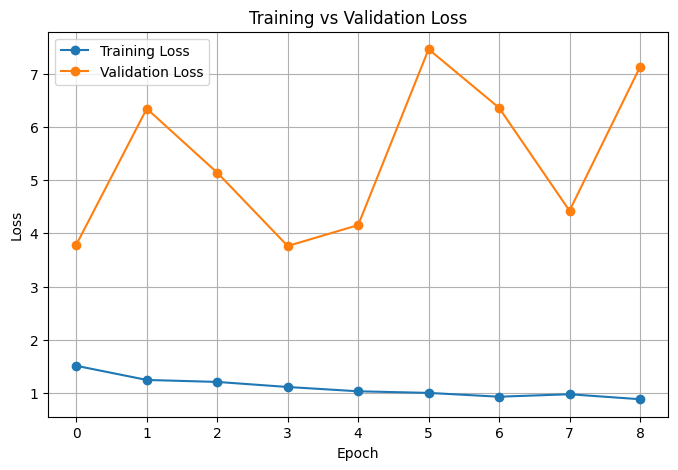

In [23]:
# Plot training & validation loss curves
history = trained_model.history

plt.figure(figsize=(8, 5))
plt.plot(history['loss'], marker='o', label='Training Loss')
plt.plot(history['val_loss'], marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
trained_model_1 = trained_model

In [25]:
save_model = False

if save_model == True:
    file_path = "models/trained_model_1.pkl"
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    with open(file_path, "wb") as f:
        pickle.dump(trained_model_1, f)
    print(f"Saved trained_model_1 to '{file_path}'")

In [26]:
def save_model(file_path, model):
    """
    Save a Python object (e.g., trained model/history) to disk using pickle.

    Parameters
    ----------
    file_path : str
        Destination path for the output `.pkl` file. Parent directories are
        created automatically if they do not exist.
    model : object
        Python object to serialize and save.

    Returns
    -------
    None
        This function writes the object to disk and prints a confirmation message.

    Notes
    -----
    This function uses `pickle`, so load the file only in trusted environments.
    """
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    with open(file_path, "wb") as f:
        pickle.dump(model, f)

    print(f"Saved model to '{file_path}'")


In [27]:
# Same structure but train on more epochs

commence_model_training = False
load_previous_model = True

if commence_model_training == True:
    trained_model_2 = model.fit(datagen.flow(X_train, y_train, batch_size=64, shuffle = True),
                            epochs=30,
                            validation_data=(X_val, y_val),
                            callbacks=[early_stopping])
if load_previous_model == True:
    trained_model_2 = pickle.load(open("models/trained_model_2.pkl", "rb"))

In [28]:
save_model = False

if save_model == True:
    save_model(file_path="models/trained_model_2.pkl",model=trained_model_2)

In [29]:
# Tuned model 1 (trained model 3):

model = Sequential([
    Conv2D(32, (3,3), padding="same", activation="relu", input_shape=X_train[0].shape),
    BatchNormalization(),
    Conv2D(32, (3,3), padding="same", activation="relu"),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(128, (3,3), padding="same", activation="relu"),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(4, activation="softmax")
])

# Main changes:

# - use padding="same"
# - gradually increase filters
# - add pooling in every conv block
# - use GlobalAveragePooling2D() instead of Flatten()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,868 (1.16 MB)

 Trainable params: 304,164 (1.16 MB)

 Non-trainable params: 704 (2.75 KB)

In [30]:
# Slightly different callbacks:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

In [32]:
commence_model_training = True
load_previous_model = False

if commence_model_training == True:
    trained_model_3 = model.fit(X_train,y_train,
                            epochs=10,
                            validation_data=(X_val, y_val),
                            callbacks=callbacks)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 268ms/step - accuracy: 0.4579 - loss: 1.3500 - val_accuracy: 0.2838 - val_loss: 1.4123 - learning_rate: 1.0000e-04
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 267ms/step - accuracy: 0.5251 - loss: 1.2208 - val_accuracy: 0.2838 - val_loss: 1.5122 - learning_rate: 1.0000e-04
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 266ms/step - accuracy: 0.5713 - loss: 1.1663 - val_accuracy: 0.2838 - val_loss: 1.8268 - learning_rate: 1.0000e-04
Epoch 4/10
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.5965 - loss: 1.0807
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 266ms/step - accuracy: 0.5786 - loss: 1.1076 - val_accuracy: 0.2838 - val_loss: 1.9435 - learning_rate: 1.0000e-04
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 267ms/step - accuracy: 0.5859 - loss: 1.1051 - val_accuracy: 0.2882 - val_loss: 2.0928 - learning_rate: 5.0000e-05
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - accuracy:

Doing some checks to see why accuracy is so bad:

In [35]:
# 1) Data shapes and types:

print(X_train.shape, X_val.shape)
print(X_train.dtype, X_val.dtype)
print(X_train.min(), X_train.max())
print(X_val.min(), X_val.max())
print(y_train.shape, y_val.shape)

(2055, 128, 128, 1) (229, 128, 128, 1)
float32 float32
0.0 1.0
0.0 1.0
(2055, 4) (229, 4)


In [34]:
# X_train and X_val shapes are the same => Good
# ..so are their data-types
# Values between 0 and 1 indicate correct scaling for train and val.

In [38]:
# 2) Class imbalance:

print(np.sum(y_train, axis=0))
print(np.sum(y_val, axis=0))

# Looks ok. We accounted for class imbalances during data preparation

[583. 590. 315. 567.]
[65. 66. 35. 63.]


All seems ok. Next step will be to read papers on similar projects